# SHMS SIMC 蒙特卡洛预训练笔记本

本笔记本用于执行 Stage 1 预训练（SIMC Monte Carlo 数据）。
流程与仓库 `training/scripts/run_pretrain.py` 保持一致，并按数据交接约定组织输入变量与输出目标。

当前版本默认读取 `mc-single-arm` 生成并合并后的 `.npz`（键 `ntuple`）。
若你的输入改为 ROOT，可按 `SIMCDataset` 的 branch 映射方式调整加载单元。

> 使用前请先修改 `NPZ_FILE` 为你的合并数据路径，并将 `OVERRIDE_P0` 设置为该批数据对应的中心动量（GeV/c）。

## 数据交接变量约定（SIMC -> 内部字段）

| SIMC branch | 内部字段 | 含义 |
|---|---|---|
| `hsxfp` | `x_fp` | 焦平面 x (cm) |
| `hsyfp` | `y_fp` | 焦平面 y (cm) |
| `hsxpfp` | `xp_fp` | 焦平面 x' (rad) |
| `hsypfp` | `yp_fp` | 焦平面 y' (rad) |
| `hsdeltai` | `delta` | 抛掷动量偏差 (%) |
| `hsxptari` | `xptar` | 靶面 θ (rad) |
| `hsyptari` | `yptar` | 靶面 φ (rad) |
| `hsztari` | `ytar` | 反应点 z (cm) |

补充特征：
- `x_tar`：按高斯噪声合成，标准差由 `x_tar_sigma_cm` 指定；
- `p0`：中心动量常量列（可固定或按配置抽样）。

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt

from training.data.preprocessing import ScalerBundle
from training.models.residual_mlp import ResidualMLP
from training.models.physics_loss import PhysicsInformedLoss
from training.trainers.pretrain import PretrainTrainer

In [2]:
# ===== 用户配置 =====
# 指定配置文件路径
CONFIG_PATH = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\SHMS_Calibration_NN\\training\\configs\\pretrain_config.yaml')

# 使用合并的 npz 数据文件作为训练数据
NPZ_FILE = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\mc-single-arm_rebuild\\python\\shms_3foil_nosieve_merged.npz')  # 合并产生的 npz 文件路径
OUTPUT_DIR = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\SHMS_Calibration_NN\\checkpoints\\pretrain')
OVERRIDE_P0 = 4.4    # 示例值：请改成当前数据交接文件对应的中心动量（GeV/c）
MAX_EVENTS = None    # 例如 300000；None 表示不截断
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 训练历史占位（避免后续单元在未训练时引用报错）
history = None

assert CONFIG_PATH.exists(), f'Config not found: {CONFIG_PATH}'
assert NPZ_FILE.exists(), f'NPZ file not found: {NPZ_FILE}'
assert OVERRIDE_P0 is not None, '请设置 OVERRIDE_P0（例如 4.4）以启用 p0 输入列'

with open(CONFIG_PATH, 'r', encoding='utf-8') as fh:
    config = yaml.safe_load(fh)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
config.setdefault('output', {})['checkpoint_dir'] = str(OUTPUT_DIR)
config['output']['scaler_save_path'] = str(OUTPUT_DIR / 'scaler_bundle.json')

print(f'Using device: {DEVICE}')
print(f'NPZ file: {NPZ_FILE}')
print(f'Output dir: {OUTPUT_DIR}')

Using device: cuda
NPZ file: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm_rebuild\python\shms_3foil_nosieve_merged.npz
Output dir: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\checkpoints\pretrain


In [3]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset

# 加载 npz 文件（与 mc-single-arm 生成格式对齐）
npz_data = np.load(NPZ_FILE, allow_pickle=False)
print(f'NPZ 文件包含的 keys: {list(npz_data.files)}')

if 'ntuple' not in npz_data.files:
    raise ValueError('NPZ 文件不包含 ntuple，无法继续处理')

ntuple = npz_data['ntuple']
print(f'ntuple 类型: {type(ntuple)}')
print(f'ntuple 形状: {ntuple.shape}')

# 目标内部字段顺序必须是: [delta, xptar, yptar, ytar]

# 可配置：优先使用真实 xtar（推荐）
USE_TRUE_XTAR = True

# 情形 A：结构化数组（带字段名）
if isinstance(ntuple, np.ndarray) and ntuple.dtype.names:
    print(f'ntuple 是结构化数组，包含字段: {ntuple.dtype.names}')
    input_branches = ['hsxfp', 'hsyfp', 'hsxpfp', 'hsypfp']
    target_branches = ['hsdeltai', 'hsxptari', 'hsyptari', 'hsztari']

    missing_inputs = [b for b in input_branches if b not in ntuple.dtype.names]
    missing_targets = [b for b in target_branches if b not in ntuple.dtype.names]
    if missing_inputs or missing_targets:
        raise ValueError(
            f'结构化数组缺少必要字段: inputs={missing_inputs}, targets={missing_targets}'
        )

    X_raw_base = np.column_stack([ntuple[b] for b in input_branches]).astype(np.float32)
    Y_raw = np.column_stack([ntuple[b] for b in target_branches]).astype(np.float32)
    x_tar_true = None  # 结构化分支未约定真实 xtar 字段名，默认回退噪声

# 情形 B：普通二维数组（mc-single-arm 的 ntuple 格式）
else:
    if not (isinstance(ntuple, np.ndarray) and ntuple.ndim == 2):
        raise ValueError(
            f'ntuple 必须是二维数组，当前类型/维度: {type(ntuple)} / {getattr(ntuple, "ndim", None)}'
        )

    n_cols = ntuple.shape[1]
    print(f'检测到二维 ntuple，共 {n_cols} 列')

    # mc_single_arm.py (SHMS, ispec==2) 写入顺序：
    # [0]x_fp [1]y_fp [2]xp_fp [3]yp_fp [4]ytar(=zreact) [5]ytar_init_aux
    # [6]delta [7]xptar(theta) [8]yptar(phi) [9..]recon/辅助信息 [14]xtar_init
    if n_cols >= 23:
        input_cols = [0, 1, 2, 3]
        target_cols = [6, 7, 8, 4]  # internal: [delta, xptar, yptar, ytar]
        print('使用 mc-single-arm SHMS(23列) 映射:')
        print('  inputs = [0,1,2,3] -> [x_fp,y_fp,xp_fp,yp_fp]')
        print('  targets= [6,7,8,4] -> [delta,xptar,yptar,ytar]')
        x_tar_true = ntuple[:, 14].astype(np.float32)
    elif n_cols >= 8:
        # 兼容兜底：仅当你使用的是“已裁剪的8列紧凑数组”
        input_cols = [0, 1, 2, 3]
        target_cols = [4, 5, 6, 7]
        print('⚠️ 检测到紧凑二维数组，使用兜底映射 [0:4] + [4:8]。')
        print('⚠️ 若来源是 mc-single-arm 原始 ntuple，请确认你没有误传文件。')
        x_tar_true = None
    else:
        raise ValueError(f'二维 ntuple 列数不足，当前 {n_cols} 列，至少需要 8 列')

    max_needed = max(max(input_cols), max(target_cols)) + 1
    if n_cols < max_needed:
        raise ValueError(f'数组列数不足。形状: {ntuple.shape}，需要至少 {max_needed} 列')

    X_raw_base = ntuple[:, input_cols].astype(np.float32)
    Y_raw = ntuple[:, target_cols].astype(np.float32)

print(f'原始数据形状(未加x_tar/p0): X={X_raw_base.shape}, Y={Y_raw.shape}')

# 应用最大事件数限制
if MAX_EVENTS is not None:
    X_raw_base = X_raw_base[:MAX_EVENTS]
    Y_raw = Y_raw[:MAX_EVENTS]
    if 'x_tar_true' in locals() and x_tar_true is not None:
        x_tar_true = x_tar_true[:MAX_EVENTS]

# 构造 x_tar 特征：优先真实 xtar，其次高斯噪声
x_tar_sigma = config.get('data', {}).get('x_tar_sigma_cm', 0.1)
seed = config.get('training', {}).get('random_seed', 42)
rng = np.random.default_rng(seed)

if USE_TRUE_XTAR and ('x_tar_true' in locals()) and (x_tar_true is not None):
    x_tar = x_tar_true.astype(np.float32)
    x_tar_source = 'true_xtar(ntuple[:,14])'
else:
    x_tar = rng.normal(0.0, x_tar_sigma, size=(len(X_raw_base),)).astype(np.float32)
    x_tar_source = 'synthetic_gaussian'

X_raw = np.column_stack([X_raw_base, x_tar])

# 添加 p0 常数列
X_raw = np.column_stack([X_raw, np.full(len(X_raw), OVERRIDE_P0, dtype=np.float32)])
print(f'x_tar source: {x_tar_source}')

# 拟合 scaler
scaler_X = StandardScaler().fit(X_raw)
scaler_Y = StandardScaler().fit(Y_raw)

X = scaler_X.transform(X_raw).astype(np.float32)
Y = scaler_Y.transform(Y_raw).astype(np.float32)

# 转换为 PyTorch 张量并创建简单数据加载器
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

class SimpleDataset(Dataset):
    """Simple in-memory dataset wrapper compatible with PyTorch Dataset."""

    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        self.scaler_X = None
        self.scaler_Y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 每个 target 返回 shape=(1,)；DataLoader 拼 batch 后得到 (B,1)
        return {
            'inputs': self.X[idx],
            'targets': {
                'delta': self.Y[idx, 0:1],
                'xptar': self.Y[idx, 1:2],
                'yptar': self.Y[idx, 2:3],
                'ytar': self.Y[idx, 3:4],
            }
        }

    def set_scalers(self, scaler_x, scaler_y):
        """Set the scalers for later reference."""
        self.scaler_X = scaler_x
        self.scaler_Y = scaler_y

dataset = SimpleDataset(X_tensor, Y_tensor)
dataset.set_scalers(scaler_X, scaler_Y)
print(f'数据集大小: {len(dataset)}')
sample = dataset[0]
print('Input shape:', tuple(sample['inputs'].shape))
print('Target keys:', list(sample['targets'].keys()))
print('Target sample shapes:', {k: tuple(v.shape) for k, v in sample['targets'].items()})

NPZ 文件包含的 keys: ['ntuple', 'merge_sources', 'merge_labels']
ntuple 类型: <class 'numpy.ndarray'>
ntuple 形状: (300000, 23)
检测到二维 ntuple，共 23 列
使用 mc-single-arm SHMS(23列) 映射:
  inputs = [0,1,2,3] -> [x_fp,y_fp,xp_fp,yp_fp]
  targets= [6,7,8,4] -> [delta,xptar,yptar,ytar]
原始数据形状(未加x_tar/p0): X=(300000, 4), Y=(300000, 4)
x_tar source: true_xtar(ntuple[:,14])
数据集大小: 300000
Input shape: (6,)
Target keys: ['delta', 'xptar', 'yptar', 'ytar']
Target sample shapes: {'delta': (1,), 'xptar': (1,), 'yptar': (1,), 'ytar': (1,)}


In [4]:
has_p0 = int(sample['inputs'].shape[0]) == 6
input_features = ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar'] + (['p0'] if has_p0 else [])
target_features = ['delta', 'xptar', 'yptar', 'ytar']
bundle = ScalerBundle(input_features=input_features, target_features=target_features)

# 使用已拟合的 scaler
bundle.set_fitted_scalers(scaler_X, scaler_Y)
bundle.save(config['output']['scaler_save_path'])
print('已保存 scaler bundle:', config['output']['scaler_save_path'])

已保存 scaler bundle: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\checkpoints\pretrain\scaler_bundle.json


In [5]:
RUN_TRAIN=False
mcfg = config.get('model', {})
lcfg = config.get('loss', {})

model_input_dim = int(sample['inputs'].shape[0])
model = ResidualMLP(
    input_dim=model_input_dim,
    hidden_dim=mcfg.get('hidden_dim', 256),
    n_residual_blocks=mcfg.get('n_residual_blocks', 4),
    branch_dim=mcfg.get('branch_dim', 64),
)

loss_fn = PhysicsInformedLoss(
    lambda_physics=lcfg.get('lambda_physics', 0.01),
    use_huber=lcfg.get('use_huber', True),
    huber_delta=lcfg.get('huber_delta', 1.0),
    transport_matrix=lcfg.get('transport_matrix', None),
)

trainer = PretrainTrainer(model=model, loss_fn=loss_fn, config=config, device=DEVICE)
history = trainer.train(train_dataset=dataset, checkpoint_dir=str(OUTPUT_DIR))

# 确保 history 是字典，而不是 map 对象
if isinstance(history, map):
    history = dict(history)

print('Training completed.')
print('Best checkpoint:', OUTPUT_DIR / 'best_pretrain.pth')

c:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\training\trainers\pretrain.py:126: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
c:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\training\trainers\pretrain.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
c:\Users\Lanto\miniconda3\envs\general\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Epoch    1/200]  train=1.44415  val=1.37990  delta=0.9814  xptar=1.0017  yptar=0.6343  ytar=0.8022  (6.7s)
[Epoch    2/200]  train=1.38895  val=1.37594  delta=0.9792  xptar=1.0021  yptar=0.6306  ytar=0.8005  (15.1s)
[Epoch    3/200]  train=1.38783  val=1.37416  delta=0.9794  xptar=1.0017  yptar=0.6293  ytar=0.8021  (16.6s)
[Epoch    4/200]  train=1.38679  val=1.37738  delta=0.9798  xptar=1.0018  yptar=0.6301  ytar=0.8115  (16.6s)
[Epoch    5/200]  train=1.38614  val=1.37541  delta=0.9796  xptar=1.0018  yptar=0.6302  ytar=0.8012  (16.4s)
[Epoch    6/200]  train=1.38635  val=1.37406  delta=0.9789  xptar=1.0017  yptar=0.6295  ytar=0.8036  (16.6s)
[Epoch    7/200]  train=1.38620  val=1.37508  delta=0.9805  xptar=1.0016  yptar=0.6290  ytar=0.8070  (11.9s)
[Epoch    8/200]  train=1.38601  val=1.37658  delta=0.9790  xptar=1.0020  yptar=0.6328  ytar=0.8091  (15.8s)
[Epoch    9/200]  train=1.38587  val=1.37571  delta=0.9819  xptar=1.0016  yptar=0.6291  ytar=0.8038  (15.7s)
[Epoch   10/200]  tr

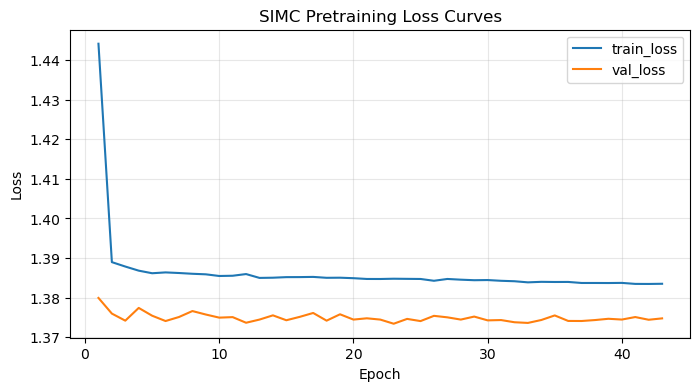

In [6]:
if history is None:
    print('history is None。请先在上一单元将 RUN_TRAIN=True 并完成训练。')
else:
    epochs = np.arange(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SIMC Pretraining Loss Curves')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

=== 每个head最佳RMSE（验证集）===
 delta: best_rmse=0.978863 @ epoch 6
 xptar: best_rmse=1.001630 @ epoch 11
 yptar: best_rmse=0.629031 @ epoch 7
  ytar: best_rmse=0.797637 @ epoch 13


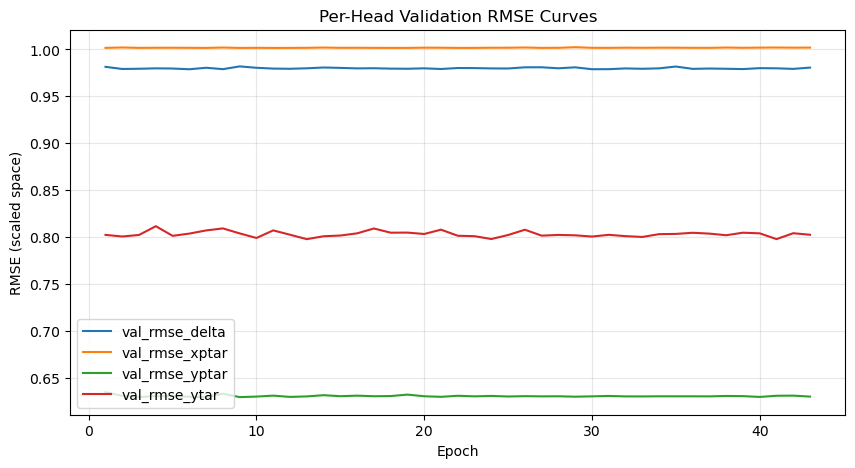

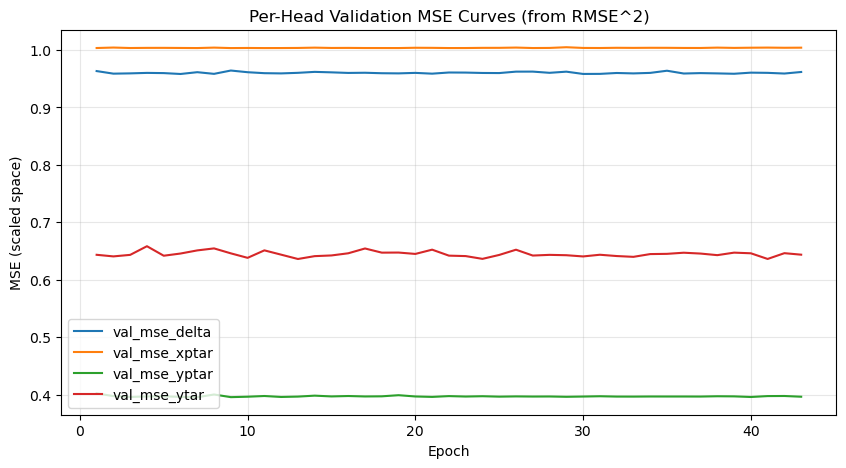


=== 最终 epoch 各 head 的 val_loss ===
 delta: 0.961650
 xptar: 1.003960
 yptar: 0.396536
  ytar: 0.643733


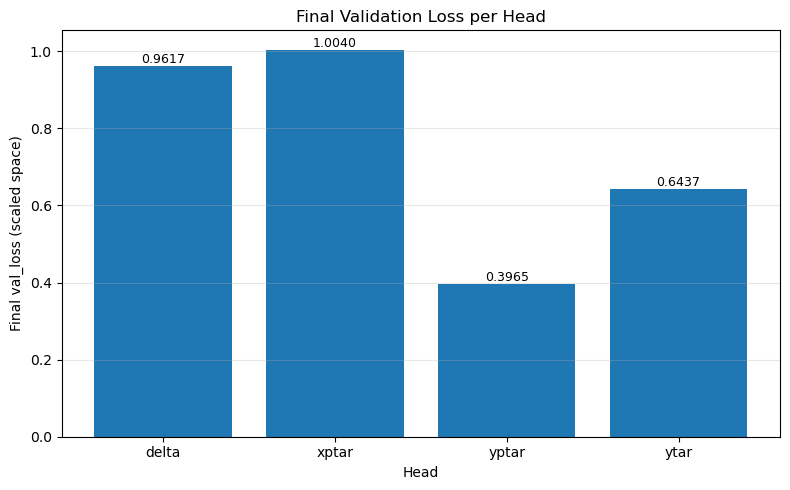

In [10]:
# 分head监控：分别打印并绘制每个head的验证误差曲线（RMSE/MSE）
import json
from pathlib import Path

# 优先使用内存中的 history；若不存在则从磁盘加载
hist = None
if 'history' in globals() and isinstance(history, dict) and 'val_loss' in history:
    hist = history
else:
    hist_path = None
    if 'OUTPUT_DIR' in globals():
        hist_path = Path(OUTPUT_DIR) / 'training_history_pretrain.json'
    else:
        hist_path = Path('checkpoints/pretrain/training_history_pretrain.json')

    if hist_path.exists():
        with open(hist_path, 'r', encoding='utf-8') as f:
            hist = json.load(f)
        print(f'从文件加载 history: {hist_path}')
    else:
        raise FileNotFoundError(f'未找到 history，请先训练或确认文件存在: {hist_path}')

head_keys = ['delta', 'xptar', 'yptar', 'ytar']
rmse_keys = [f'val_rmse_{k}' for k in head_keys]
missing = [k for k in rmse_keys if k not in hist]
if missing:
    raise KeyError(f'history 中缺少这些分head指标: {missing}')

epochs = np.arange(1, len(hist['val_loss']) + 1)

print('=== 每个head最佳RMSE（验证集）===')
for k in head_keys:
    arr = np.array(hist[f'val_rmse_{k}'], dtype=np.float64)
    best_idx = int(np.argmin(arr))
    print(f'{k:>6}: best_rmse={arr[best_idx]:.6f} @ epoch {best_idx + 1}')

# 画图1：每个head的RMSE曲线
plt.figure(figsize=(10, 5))
for k in head_keys:
    arr = np.array(hist[f'val_rmse_{k}'], dtype=np.float64)
    plt.plot(epochs, arr, label=f'val_rmse_{k}')
plt.xlabel('Epoch')
plt.ylabel('RMSE (scaled space)')
plt.title('Per-Head Validation RMSE Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 画图2：每个head的MSE曲线（RMSE^2，便于对总loss贡献做直观比较）
plt.figure(figsize=(10, 5))
for k in head_keys:
    arr = np.array(hist[f'val_rmse_{k}'], dtype=np.float64) ** 2
    plt.plot(epochs, arr, label=f'val_mse_{k}')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled space)')
plt.title('Per-Head Validation MSE Curves (from RMSE^2)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 画图3：最终 epoch 各 head 的 val_loss 条形图
# 优先读取 val_loss_{head}，若不存在则尝试 val_mse_{head}，再回退为 val_rmse_{head}^2
final_val_loss = {}
for k in head_keys:
    key_loss = f'val_loss_{k}'
    key_mse = f'val_mse_{k}'
    key_rmse = f'val_rmse_{k}'

    if key_loss in hist:
        final_val_loss[k] = float(np.array(hist[key_loss], dtype=np.float64)[-1])
    elif key_mse in hist:
        final_val_loss[k] = float(np.array(hist[key_mse], dtype=np.float64)[-1])
    else:
        rmse_last = float(np.array(hist[key_rmse], dtype=np.float64)[-1])
        final_val_loss[k] = rmse_last ** 2

print('\n=== 最终 epoch 各 head 的 val_loss ===')
for k in head_keys:
    print(f'{k:>6}: {final_val_loss[k]:.6f}')

labels = head_keys
values = [final_val_loss[k] for k in labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.xlabel('Head')
plt.ylabel('Final val_loss (scaled space)')
plt.title('Final Validation Loss per Head')
plt.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# 可选：快速检查 checkpoint 可加载性
ckpt_path = OUTPUT_DIR / 'best_pretrain.pth'
assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'
ckpt = torch.load(ckpt_path, map_location='cpu')
print('Saved epoch:', ckpt.get('epoch'))
print('Saved val_loss:', ckpt.get('val_loss'))
print('Checkpoint keys:', sorted(list(ckpt.keys())))

Saved epoch: 23
Saved val_loss: 1.373381826845805
Checkpoint keys: ['config', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss']


C:\Users\Lanto\AppData\Local\Temp\ipykernel_22988\2999812455.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')
